# Tests involving the NeuralODE code

First, we need to set up the NeuralODE and test that we can access all that matters

56


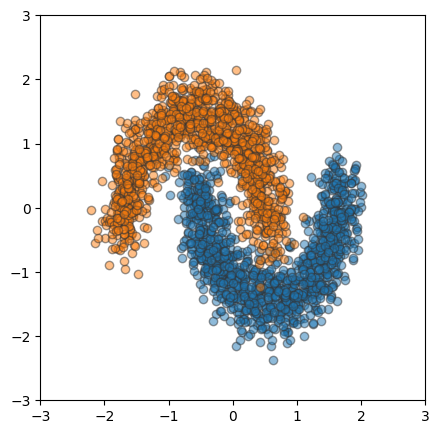

In [35]:
from models.neural_odes import NeuralODE
from models.training import visualize_dataloader
from minimal_neuralODE import build_neuralODE, plot_data
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from Lyapunov_toolbox import local_FTLE


nODE, dataloader = build_neuralODE(trained = False, data = True)


Then, we want to test that the derivative we are retrieving makes sense w.r.t. the right hand side

We check this by comparign with a numerical derivative taken with the standard finite difference method

In [36]:
def finite_differences(f, t, x, eps = 0.1):
    x_temp = torch.clone(x)
    der = torch.empty(f(t,x).shape[0], x.shape[0])
    for i in range(len(x)):
        x_temp[i] = x[i] + eps
        der[:,i] = (f(t,x_temp) - f(t,x))/eps
        x_temp[i] = x[i]  # change back
    return der

In [37]:
t = 0
x = torch.Tensor([2.3, 1.4])
finite_differences(nODE.flow.dynamics.forward, t, x) 

tensor([[ 0.1001,  0.0141],
        [-0.1286,  0.3713]], grad_fn=<CopySlices>)

0 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]]) 
 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]])
tensor(4.4874e-06)
1 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]]) 
 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]])
tensor(1.4732e-05)
2 tensor([[10.2999,  1.4000],
        [12.3001,  9.1000]]) 
 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]])
tensor(0.0002)
3 tensor([[10.2997,  1.4000],
        [12.3024,  9.1019]]) 
 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]])
tensor(0.0031)
4 tensor([[10.2806,  1.3924],
        [12.3215,  9.0790]]) 
 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]])
tensor(0.0366)
5 tensor([[10.2997,  1.3351],
        [12.5885,  9.1553]]) 
 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]])
tensor(0.3008)
6 tensor([[ 9.5367,  1.9073],
        [15.2588,  7.6294]]) 
 tensor([[10.3000,  1.4000],
        [12.3000,  9.1000]])
tensor(3.4289)


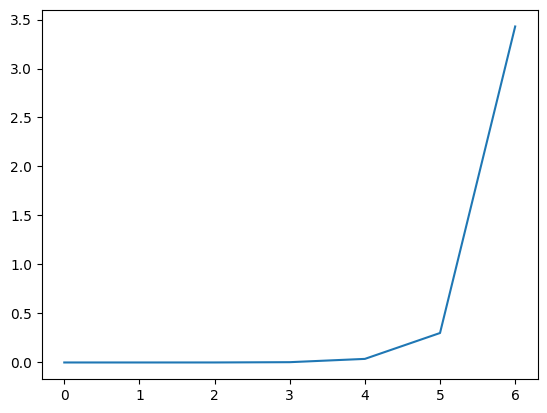

In [38]:
x = torch.Tensor([2.3, 1.4])
y = torch.Tensor([[2.3, 1.4],[12.3, 1.1]])
x_mat = torch.diag_embed(x)

silly_function = lambda t, x : x*8 + y.matmul(x)
derivative = lambda t, x : 8*torch.eye(2) + y

error = torch.empty(7)
for i in range(7):
    print(i,finite_differences(silly_function, t, x, eps=10**-i), '\n', derivative(t, x))
    error[i] = torch.norm(finite_differences(silly_function, t, x, eps=10**-i) - derivative(t, x))
    print(error[i])
plt.plot(error)


In [39]:
x = torch.Tensor([2.5889,0.245678])

finite_diff = finite_differences(nODE.flow.dynamics.forward, t, x, eps=10**-3).detach()
print('finite diff\n', finite_diff)

# other option: autograd
x_torch = x
x_torch.requires_grad=True
f_x_t = lambda x: nODE.flow.dynamics.forward(t, x)
autograd = torch.autograd.functional.jacobian(f_x_t, x_torch) # symbolical (I think)
print('autograd\n', autograd)

analytical = nODE.flow.dynamics.derivative(t, x)
print('analytical\n', analytical)

print('error autograd VS finite diff', torch.norm(autograd - finite_diff))
print('error autograd VS analytic', torch.norm(autograd - analytical))

finite diff
 tensor([[ 0.0904,  0.0121],
        [-0.2064,  0.6279]])
autograd
 tensor([[ 0.0905,  0.0121],
        [-0.2064,  0.6279]])
analytical
 tensor([[ 0.0905,  0.0121],
        [-0.2064,  0.6279]])
error autograd VS finite diff tensor(0.0001)
error autograd VS analytic tensor(0.)


In [40]:
nODE.flow.dynamics.fc2_time[0].weight

Parameter containing:
tensor([[ 0.6408,  0.0858],
        [-0.2071,  0.6300]], requires_grad=True)

In [41]:
nODE.architecture

'outside'

In [42]:
tensor1 = torch.randn(4, 4)
tensor2 = torch.randn(4)
a=torch.matmul(tensor2, tensor1)
a2=torch.matmul(tensor1, tensor2)
print(a, '\n', a2)

tensor([-0.1197, -0.2145,  0.6380,  2.0064]) 
 tensor([-1.4029,  0.4888,  1.7741, -1.3354])


Now the actual FTLE test starts

In [43]:
x_amount = 10 
T = 4 
integration_time = 20
dt = 0.1
plotlim = [-3, 3]
boundary = np.abs(plotlim[0])

x = np.linspace(-boundary,boundary,x_amount) 
y = np.linspace(-boundary,boundary,x_amount) 
X, Y = np.meshgrid(x, y) 
XY = np.array([X.flatten(), Y.flatten()])

lyap = np.zeros(x_amount**2) 
start_time = time.time() 
for i in range(x_amount**2): 
    lyap[i] = np.max(local_FTLE(nODE, XY[:,i], integration_time, 0.1)) 
    iteration_time = time.time() - start_time 
    if np.mod(i, 10) == 0: 
        print(i+1,' out of ', x_amount**2, ' after ', iteration_time) 
    # print(lyap[i]) 
    #break l
lyap2 = np.reshape(lyap, (x_amount,x_amount)) 

/Users/queirolo/Desktop/GIT_repository/TUM_nODE/Lyapunov_toolbox.py:119: UserWarning: only one iteration to test results
  warnings.warn("only one iteration to test results")
/Users/queirolo/Desktop/GIT_repository/TUM_nODE/models/neural_odes.py:120: UserWarning: Extending the dynamics
  warn('Extending the dynamics')


1  out of  100  after  0.23324203491210938
11  out of  100  after  2.38411808013916
21  out of  100  after  4.438287019729614
31  out of  100  after  6.314625024795532
41  out of  100  after  8.205799102783203
51  out of  100  after  10.081885814666748
61  out of  100  after  12.069278955459595
71  out of  100  after  14.048995971679688
81  out of  100  after  16.040717124938965
91  out of  100  after  17.956668853759766


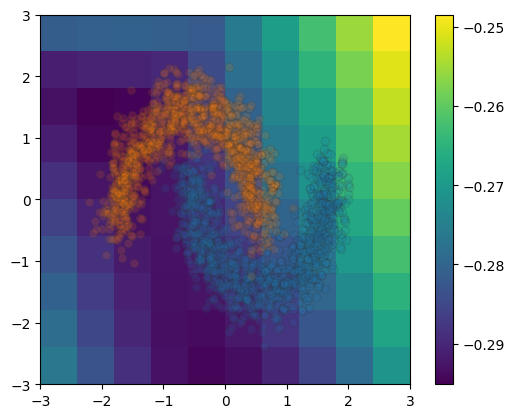

In [44]:
import matplotlib.pyplot as plt

plt.imshow(lyap2, origin='lower', extent=(-boundary, boundary, -boundary, boundary), cmap='viridis')
plt.colorbar()  # Show color scale

x, y = dataloader.dataset.tensors
plotlim = [-3, 3]    
data_0 = x[y[:,0] > 0]
data_1 = x[y[:,0] < 0]
plt.scatter(data_0[:, 0], data_0[:, 1], edgecolor="#333",  alpha = 0.15)
plt.scatter(data_1[:, 0], data_1[:, 1], edgecolor="#333", alpha = 0.15)
plt.xlim(plotlim)
plt.ylim(plotlim)
ax = plt.gca()
ax.set_aspect('equal')
plt.show()

#plt.savefig('Lyapunov_for_moons')
plt.show()

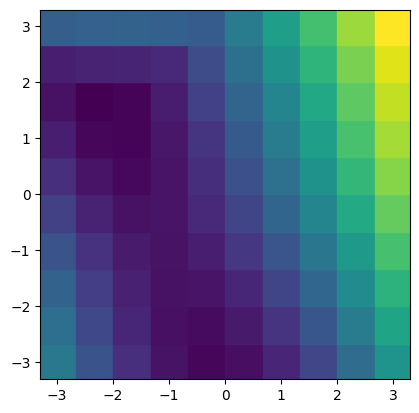

In [45]:
plt.scatter(XY[0, :], XY[1, :], c = lyap, s = 700, marker = 's')
ax = plt.gca()
ax.set_aspect('equal')

In [46]:
nODE.architecture

'outside'

In [47]:
def easy_lyap(x_amount, integration_time, f = nODE, jac = None):
    dt = 0.1
    boundary = np.abs(plotlim[0])

    x = np.linspace(-boundary,boundary,x_amount) 
    y = np.linspace(-boundary,boundary,x_amount) 
    X, Y = np.meshgrid(x, y) 
    XY = np.array([X.flatten(), Y.flatten()])

    lyap = np.zeros(x_amount**2) 
    start_time = time.time() 
    for i in range(x_amount**2): 
        if jac is None:
            lyap[i] = np.max(local_FTLE(f, XY[:,i], integration_time, 0.1)) 
        else:
            lyap[i] = np.max(local_FTLE(f, XY[:,i], integration_time, 0.1, der = jac)) 
        iteration_time = time.time() - start_time 
    return lyap

In [48]:
# analytical derivatives

f = lambda x, t: nODE.flow.dynamics.forward(t,torch.Tensor(x)).detach()
jac = lambda x, t: nODE.flow.dynamics.derivative(t,torch.Tensor(x)).detach()

autograd and normal integration time


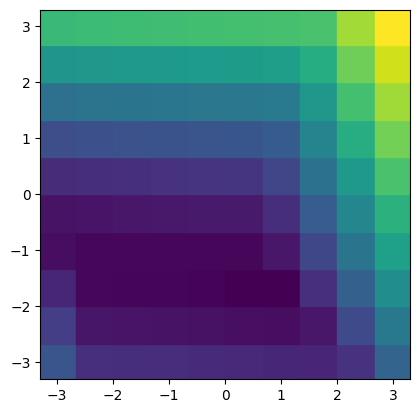

analytical derivatives, normal integration time


/Users/queirolo/Desktop/GIT_repository/TUM_nODE/models/neural_odes.py:164: UserWarning: Extending the dynamics
  warn('Extending the dynamics')


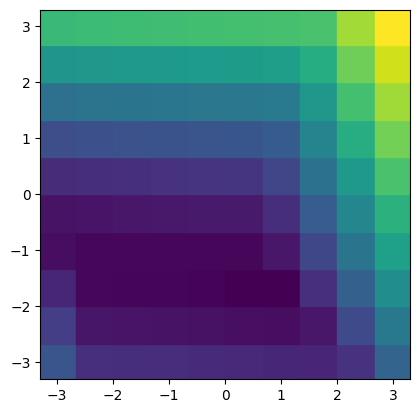

autograd, long integration


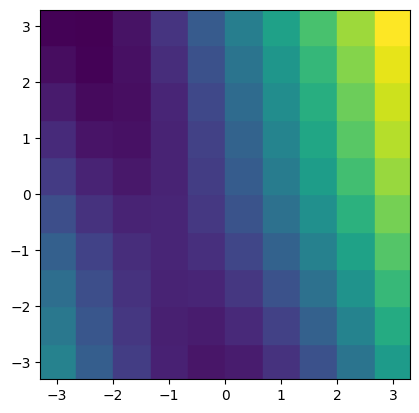

analytical, long integration time


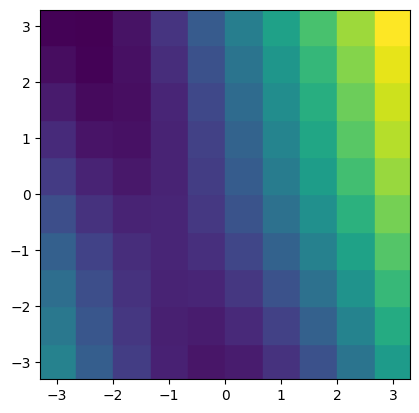

In [49]:
print('autograd and normal integration time')

lyap = easy_lyap(10, T)
plt.scatter(XY[0, :], XY[1, :], c = lyap, s = 700, marker = 's')
ax = plt.gca()
ax.set_aspect('equal')
plt.show()

print('analytical derivatives, normal integration time')

lyap = easy_lyap(10, T, f = f, jac = jac)
plt.scatter(XY[0, :], XY[1, :], c = lyap, s = 700, marker = 's')
ax = plt.gca()
ax.set_aspect('equal')
plt.show()

print('autograd, long integration')

lyap = easy_lyap(10, 10*T)
plt.scatter(XY[0, :], XY[1, :], c = lyap, s = 700, marker = 's')
ax = plt.gca()
ax.set_aspect('equal')
plt.show()

print('analytical, long integration time')

lyap = easy_lyap(10, 10*T, f = f, jac = jac)
plt.scatter(XY[0, :], XY[1, :], c = lyap, s = 700, marker = 's')
ax = plt.gca()
ax.set_aspect('equal')
plt.show()

In [50]:
T

4

In [51]:
def rowKronecker(x_vector, y_matrix):
    temp = [x_vector[i].detach() * y_matrix[i, :].detach() for i in range(len(x))]
    out = torch.Tensor()
    out = torch.cat(temp, out=out).reshape(y_matrix.shape)
    return out

w_t = torch.Tensor([[1,2],[3.,10]])
x = torch.Tensor([3,5])
b_t = 0*torch.Tensor([1.,1.])
non_linear_derivative = lambda input : 1 - torch.tanh(input) * torch.tanh(input)

y = (w_t.matmul(x) + b_t)
print(y)
f_y = non_linear_derivative(y)
print(f_y)
out = rowKronecker(non_linear_derivative(w_t.matmul(x) + b_t), w_t)
print(out)

tensor([13., 59.])
tensor([0., 0.])
tensor([[0., 0.],
        [0., 0.]])


In [52]:
out

tensor([[0., 0.],
        [0., 0.]])

In [53]:
nODE.linear_layer.weight

Parameter containing:
tensor([[-0.6839, -0.3608],
        [-0.3841,  0.6976]], requires_grad=True)

In [54]:
np.linalg.eig(nODE.linear_layer.weight.detach().numpy())

EigResult(eigenvalues=array([-0.777794 ,  0.7915908], dtype=float32), eigenvectors=array([[-0.9677383 ,  0.23755014],
       [-0.25195763, -0.9713753 ]], dtype=float32))

# Using the lyapynov library on nODEs

In [55]:
f = lambda x, t: np.array(nODE.flow.dynamics.forward(t,torch.Tensor(x)).detach())
jac_anal = lambda x, t: np.array(nODE.flow.dynamics.derivative(t,torch.Tensor(x)).detach())

In [56]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from lyapynov import ContinuousDS, DiscreteDS
from lyapynov import mLCE, LCE, CLV, ADJ

# lyap = easy_lyap(x_amount, T, f = f, jac = jac)
x0 = np.array([1,2.3])
t0 = 0
dt = 0.01
nODE_continuousSystem = ContinuousDS(x0, t0, f, jac_anal, dt)
mLCE_x, history = mLCE(nODE_continuousSystem, 0, int(T/dt), True)
print(mLCE_x)

-0.1594365584171847


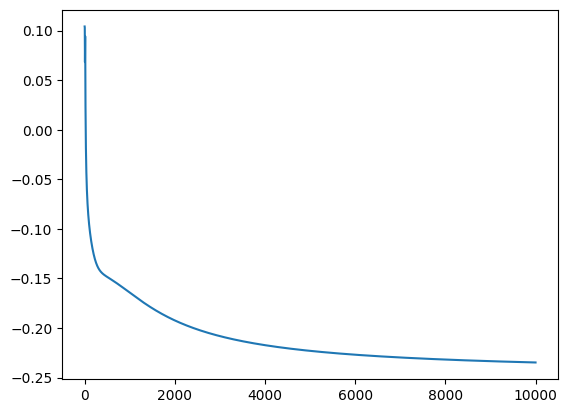

In [57]:
from lyapynov import mLCE, LCE, CLV, ADJ

def mLE(x0, end_time = T):
    t0, dt = 0, 0.01
    nODE_continuousSystem = ContinuousDS(x0, t0, f, jac_anal, dt)
    mle, history = mLCE(nODE_continuousSystem, 0, int(end_time/dt), True)
    return mle, history


mle, history = mLE(np.array([1,2.3]), 100)
plt.plot(history)

In [58]:
def lyapynov_lyap(x_amount, end_time = T):
    x = np.linspace(-boundary,boundary,x_amount) 
    y = np.linspace(-boundary,boundary,x_amount) 
    X, Y = np.meshgrid(x, y) 
    XY = np.array([X.flatten(), Y.flatten()])
    #print(XY)

    lyap = np.zeros(x_amount**2) 
    for i in range(x_amount**2): 
        x0 = XY[:,i]
        #print(x0)
        lyap[i], h = mLE(x0, end_time)
    
    #plt.scatter(XY[0, :], XY[1, :], c = lyap, s = 700, marker = 's')
    #ax = plt.gca()
    #ax.set_aspect('equal')
    #plt.show()
    return lyap

In [60]:
def overlay(lyap_vec):
    x_amount = int(np.sqrt(lyap_test.shape[0]))
    lyap2 = np.reshape(lyap_test, (x_amount,x_amount)) 
    plt.imshow(lyap2, origin='lower', extent=(-boundary, boundary, -boundary, boundary), cmap='viridis')
    plt.colorbar()  # Show color scale
    
    x, y = dataloader.dataset.tensors
    plotlim = [-3, 3]    
    data_0 = x[y[:,0] > 0]
    data_1 = x[y[:,0] < 0]
    plt.scatter(data_0[:, 0], data_0[:, 1], edgecolor="#333",  alpha = 0.15)
    plt.scatter(data_1[:, 0], data_1[:, 1], edgecolor="#333", alpha = 0.15)
    plt.xlim(plotlim)
    plt.ylim(plotlim)
    ax = plt.gca()
    ax.set_aspect('equal')

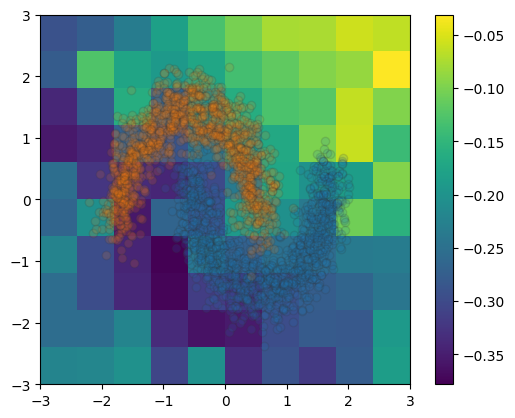

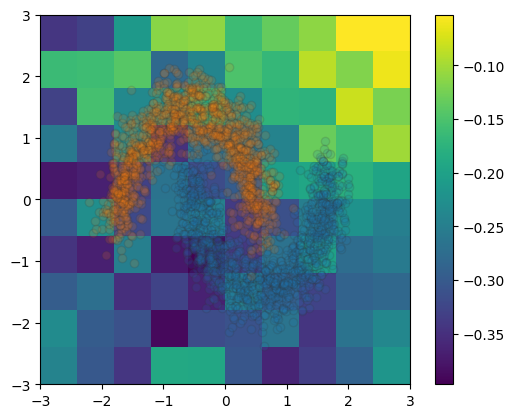

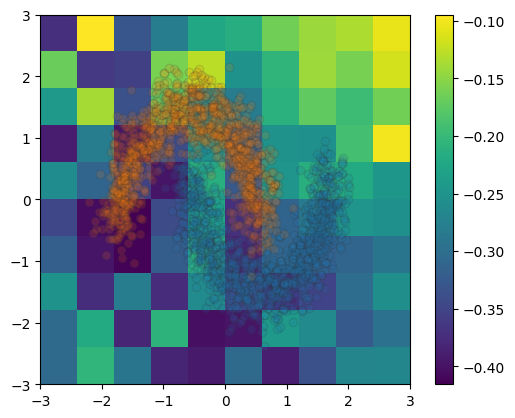

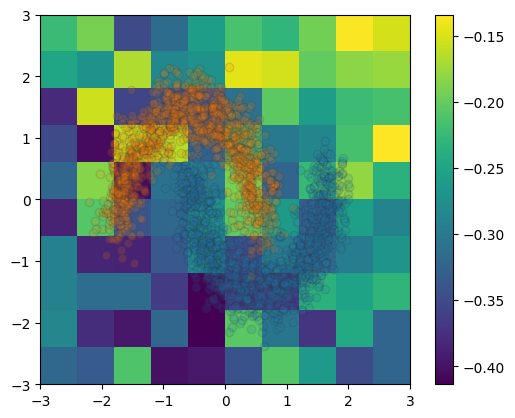

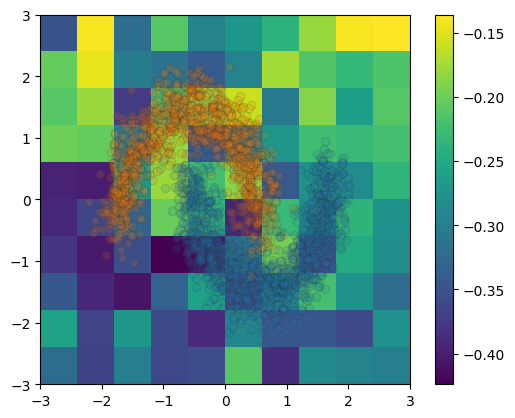

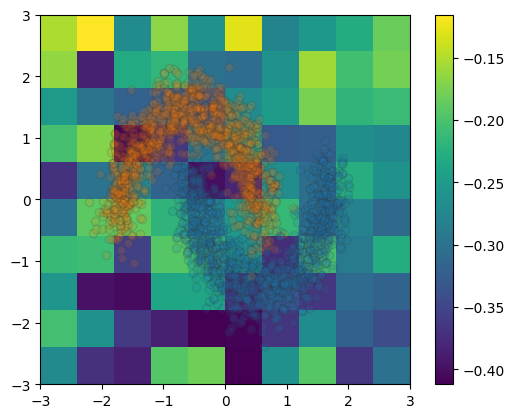

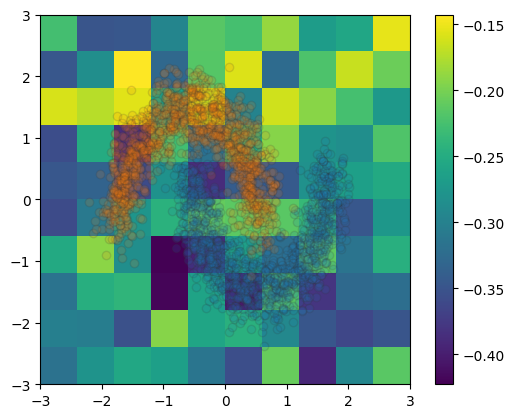

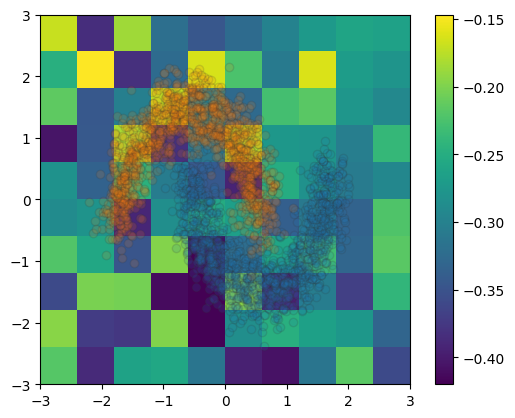

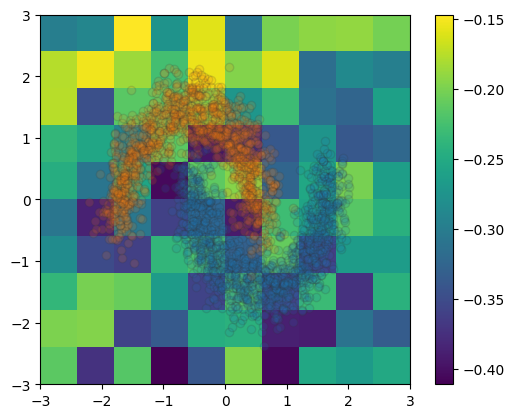

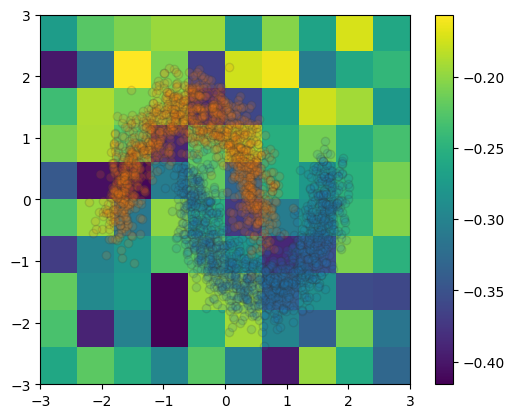

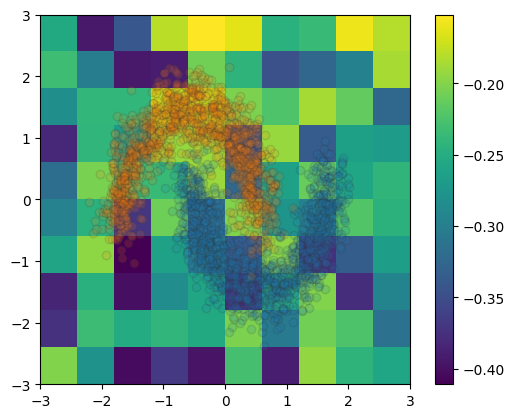

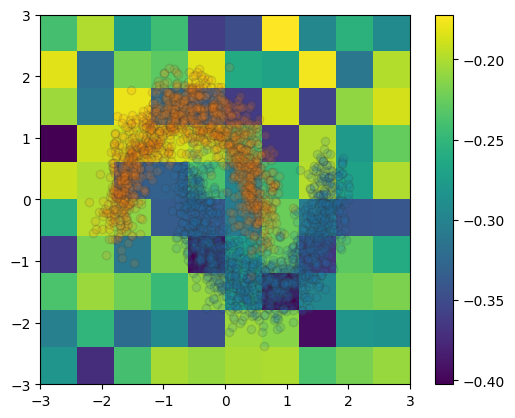

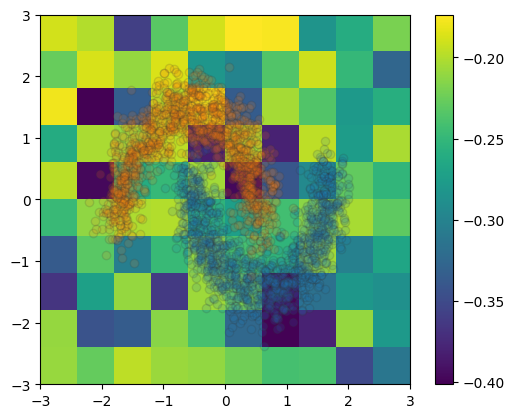

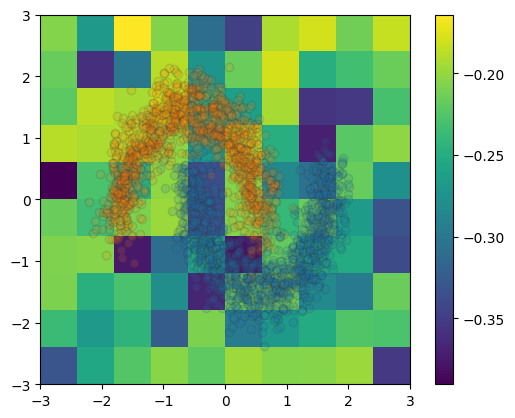

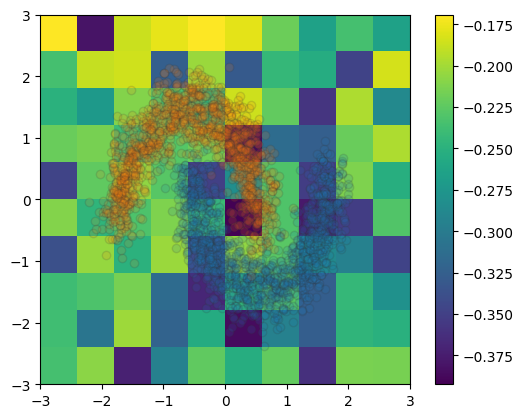

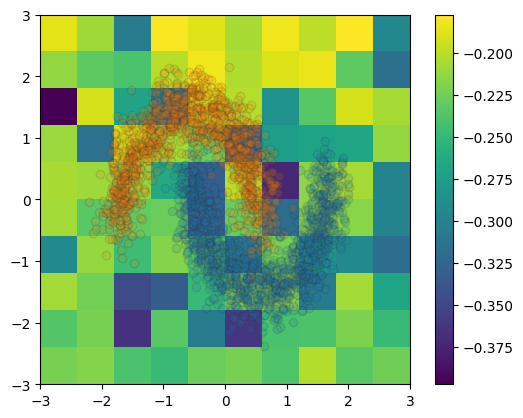

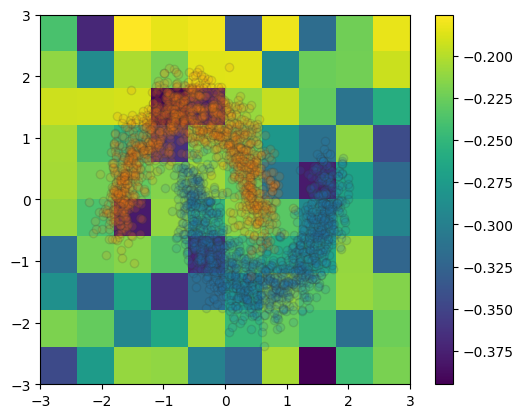

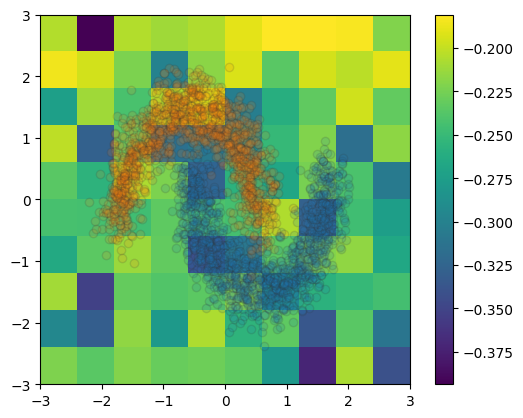

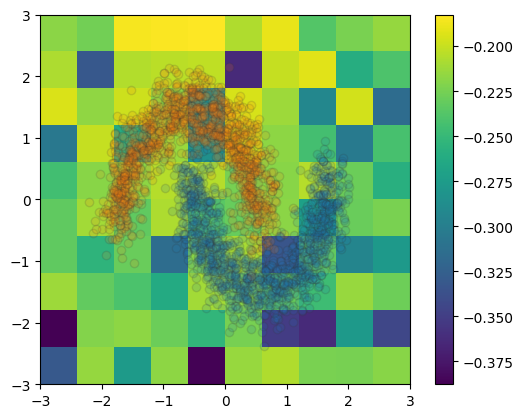

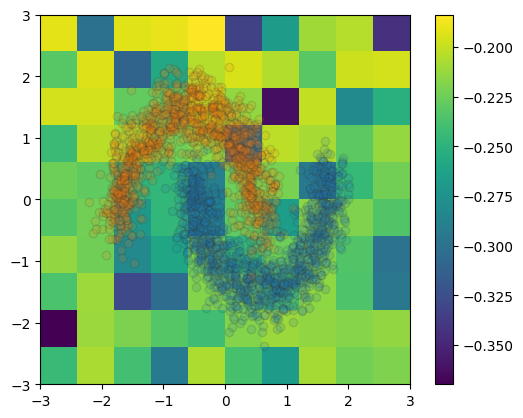

In [61]:
for end_time in range(20):
    lyap_test = lyapynov_lyap(10, 1+end_time)
    overlay(lyap_test)
    plt.show()

In [ ]:

lyap_test = lyapynov_lyap(10, 1+200)
overlay(lyap_test)
plt.show()